In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

SAVE_PATH = '/content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment-4/results/part-C/'
os.makedirs(SAVE_PATH, exist_ok=True)

In [2]:
SEPARABLE_KERNELS = {
    "Box Blur":             np.ones((3,3), dtype=np.float32) / 9.0,
    "Gaussian 3x3":         np.array([[1,2,1],[2,4,2],[1,2,1]], dtype=np.float32) / 16.0,
    "Gaussian 5x5":         np.array([[1,4,6,4,1],[4,16,24,16,4],[6,24,36,24,6],[4,16,24,16,4],[1,4,6,4,1]], dtype=np.float32) / 256.0,
    "Prewitt H":            np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=np.float32),
    "Prewitt V":            np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=np.float32),
    "Sobel H":              np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32),
    "Sobel V":              np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32),
    "Motion Blur H":        np.array([[0,0,0],[1,1,1],[0,0,0]], dtype=np.float32) / 3.0,
    "Motion Blur V":        np.array([[0,1,0],[0,1,0],[0,1,0]], dtype=np.float32) / 3.0,
    "Line Detector H":      np.array([[-1,-1,-1],[2,2,2],[-1,-1,-1]], dtype=np.float32),
}

NON_SEPARABLE_KERNELS = {
    "Laplacian 8":          np.array([[1,1,1],[1,-8,1],[1,1,1]], dtype=np.float32),
    "Laplacian 4":          np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float32),
    "Sobel Diag 45":        np.array([[0,1,2],[-1,0,1],[-2,-1,0]], dtype=np.float32),
    "Sobel Diag 135":       np.array([[-2,-1,0],[-1,0,1],[0,1,2]], dtype=np.float32),
    "Emboss":               np.array([[-2,-1,0],[-1,1,1],[0,1,2]], dtype=np.float32),
    "Kirsch E":             np.array([[-3,-3,5],[-3,0,5],[-3,-3,5]], dtype=np.float32),
    "Unsharp Mask":         np.array([[-1,-4,-1],[-4,26,-4],[-1,-4,-1]], dtype=np.float32) / 10.0,
    "Scharr H":             np.array([[3,10,3],[0,0,0],[-3,-10,-3]], dtype=np.float32),
    "Robinson N":           np.array([[1,2,1],[0,0,0],[-1,-2,-1]], dtype=np.float32),
    "Rotating Edge":        np.array([[0,-1,1],[1,0,-1],[-1,1,0]], dtype=np.float32),
}

In [3]:
def check_separability(kernel):
    U, S, Vt = np.linalg.svd(kernel)
    rank = np.sum(S > 1e-10)
    return rank == 1, int(rank)

In [4]:
def visualize_kernels(kernels, title, filename):
    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for ax, (name, kernel) in zip(axes.flatten(), kernels.items()):
        is_sep, rank = check_separability(kernel)
        ax.imshow(kernel, cmap='RdBu_r')
        for i in range(kernel.shape[0]):
            for j in range(kernel.shape[1]):
                ax.text(j, i, f'{kernel[i,j]:.2f}', ha='center', va='center', fontsize=8, fontweight='bold')
        ax.set_title(f'{name}\nRank={rank}', fontsize=9,
                     color='green' if is_sep else 'red', fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(SAVE_PATH + filename, dpi=150, bbox_inches='tight')
    plt.show()

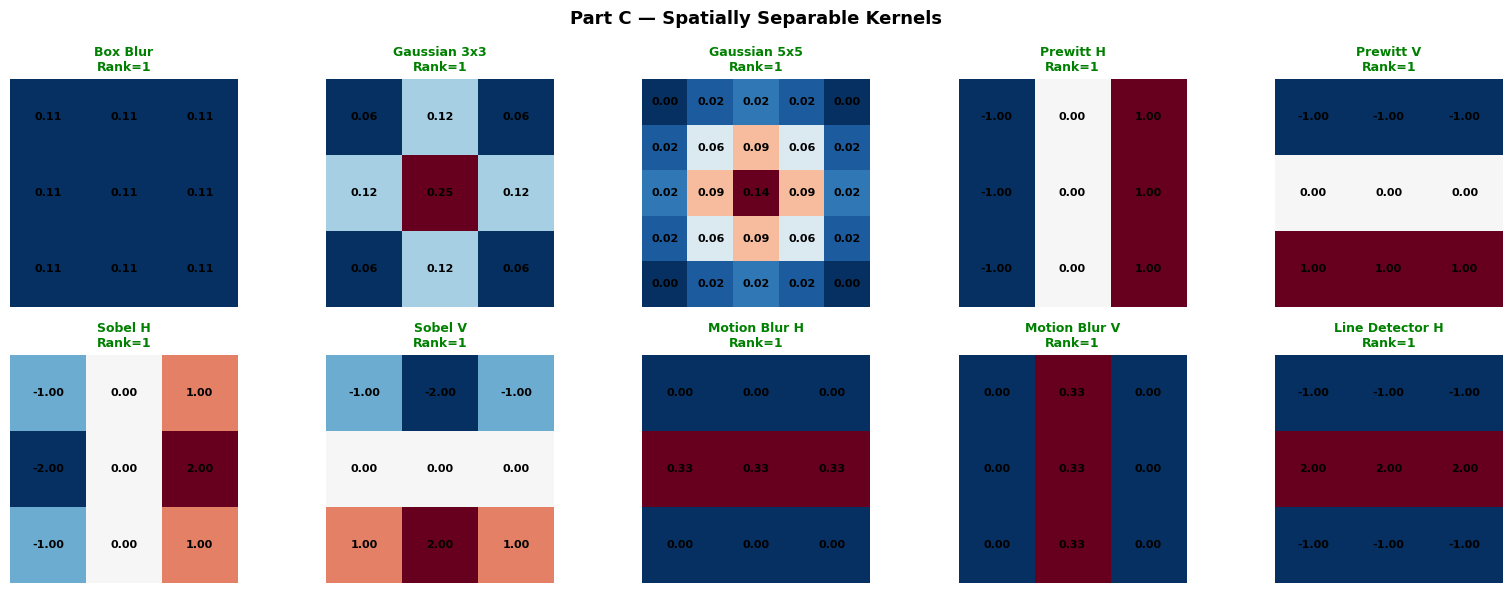

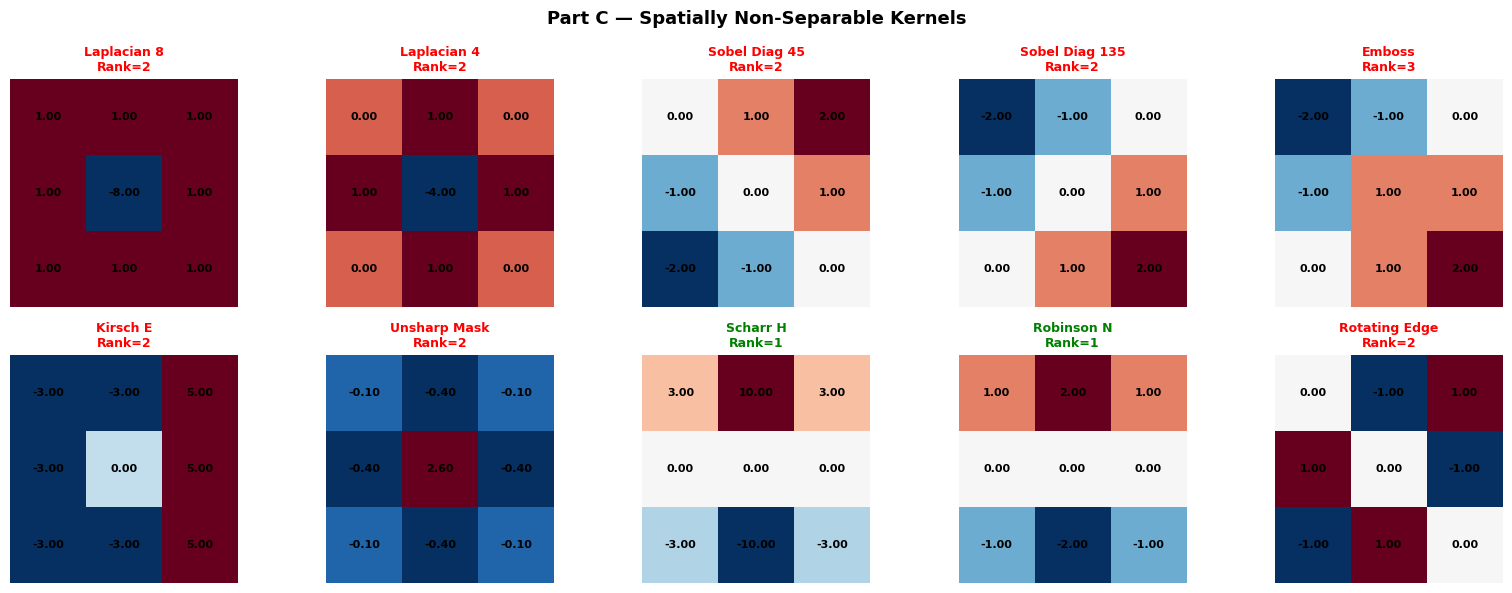

[SEP]    Box Blur             rank=1
[SEP]    Gaussian 3x3         rank=1
[SEP]    Gaussian 5x5         rank=1
[SEP]    Prewitt H            rank=1
[SEP]    Prewitt V            rank=1
[SEP]    Sobel H              rank=1
[SEP]    Sobel V              rank=1
[SEP]    Motion Blur H        rank=1
[SEP]    Motion Blur V        rank=1
[SEP]    Line Detector H      rank=1

[NOT]    Laplacian 8          rank=2
[NOT]    Laplacian 4          rank=2
[NOT]    Sobel Diag 45        rank=2
[NOT]    Sobel Diag 135       rank=2
[NOT]    Emboss               rank=3
[NOT]    Kirsch E             rank=2
[NOT]    Unsharp Mask         rank=2
[NOT]    Scharr H             rank=1
[NOT]    Robinson N           rank=1
[NOT]    Rotating Edge        rank=2


In [5]:
def main():
    visualize_kernels(SEPARABLE_KERNELS,
                      'Part C — Spatially Separable Kernels',
                      'separable_kernels.png')

    visualize_kernels(NON_SEPARABLE_KERNELS,
                      'Part C — Spatially Non-Separable Kernels',
                      'non_separable_kernels.png')

    for name, kernel in SEPARABLE_KERNELS.items():
        is_sep, rank = check_separability(kernel)
        print(f"{'[SEP]':<8} {name:<20} rank={rank}")

    print()

    for name, kernel in NON_SEPARABLE_KERNELS.items():
        is_sep, rank = check_separability(kernel)
        print(f"{'[NOT]':<8} {name:<20} rank={rank}")


main()